# Tutorial: selection analysis with eskaks

This notebook runs a complete **eskaks** analysis on the bundled example data —
no background assumed. It covers both modes and every output, using `pandas` to
read the tables and `matplotlib` to plot them.

1. **Pairwise dN/dS** from a codon-aligned FASTA (divergence between sequences).
2. **Per-gene pN/pS** from a VCF + reference + GFF3 (within-species polymorphism),
   plus the per-variant table and the interactive report.
3. **Population diversity** — πN/πS, Watterson θ and Tajima's D.

> **Tip** — Prefer the command line? Every cell here is one `eskaks` call; see the
> [CLI reference](../cli-reference/). The prose walkthrough is the
> [getting-started tutorial](../tutorial/).

## Setup

Locate (or build) the compiled binary and set the brand plot style.

In [1]:
import os, shutil, subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Run from the eskaks repo root whether launched there or from docs/.
for base in (Path("."), Path("..")):
    if (base / "Cargo.toml").exists() and (base / "examples").exists():
        os.chdir(base)
        break

ESKAKS = shutil.which("eskaks") or "target/release/eskaks"
if not Path(ESKAKS).exists():
    subprocess.run(["cargo", "build", "--release"], check=True)

OUT = Path("nb_out"); OUT.mkdir(exist_ok=True)
ACCENT, GOLD, POS, NS = "#305595", "#d1ae00", "#c01718", "#c0b3a7"  # mycolorsTB
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
})

def eskaks(*args, show=True):
    r = subprocess.run([ESKAKS, *map(str, args)], capture_output=True, text=True)
    if show:
        print((r.stdout + r.stderr).strip())
    return r

print(subprocess.run([ESKAKS, "--version"], capture_output=True, text=True).stdout.strip())

eskaks 0.1.0


## 1 · Pairwise dN/dS from FASTA

`eskaks fasta` compares codon-aligned CDS pairwise. dN/dS below 1 means
purifying selection (amino-acid changes are being removed); above 1 flags
positive/diversifying selection. We use the six sequences in `examples/genes.fasta`.

In [2]:
eskaks("fasta", "examples/genes.fasta", "--summary", "-o", OUT / "fasta");

═══ dN/dS Summary ═══
  Total pairs:     15
  Valid pairs:     15  (100.0%)
  Saturated (NaN): 0  (0.0%)

  dN:    min=0.015150  max=0.070711  mean=0.042896
  dS:    min=0.115121  max=0.418424  mean=0.265297
  dN/dS (pooled = meanDN/meanDS): 0.161688
  dN/dS (mean of per-pair ratios): min=0.077805  max=0.334646  mean=0.169602  (n=15)

  dN/dS Distribution:
  [0.0, 0.2) ████████████████████  11 ( 73.3%)
  [0.2, 0.4) ███████                4 ( 26.7%)
  [0.4, 0.6)                        0 (  0.0%)
  [0.6, 0.8)                        0 (  0.0%)
  [0.8, 1.0)                        0 (  0.0%)
  [1.0, inf)                        0 (  0.0%)
═════════════════════


── Done ───────────────────────────────────
  Sequences:  6 (6 unique) from examples/genes.fasta
  Model:      Nei-Gojobori
  Output:
    nb_out/fasta_pairwise_results.tsv
────────────────────────────────────────────


In [3]:
pairs = pd.read_csv(OUT / "fasta_pairwise_results.tsv", sep="\t")
print(f"{len(pairs)} pairs")
pairs.head(8)

15 pairs


,Seq1,Seq2,dN,dS,dN/dS
0,strain_A,strain_B,0.022990,0.164075,0.140120
1,strain_A,strain_C,0.015150,0.194718,0.077805
2,strain_A,strain_D,0.038525,0.115121,0.334646
3,strain_A,strain_E,0.038614,0.165431,0.233415
4,strain_A,strain_F,0.015178,0.140281,0.108200
5,strain_B,strain_C,0.038502,0.418424,0.092016
6,strain_B,strain_D,0.046518,0.221230,0.210270
7,strain_B,strain_E,0.062836,0.376694,0.166809


Every pair sits below the neutral line — the signal of a conserved, constrained gene set:

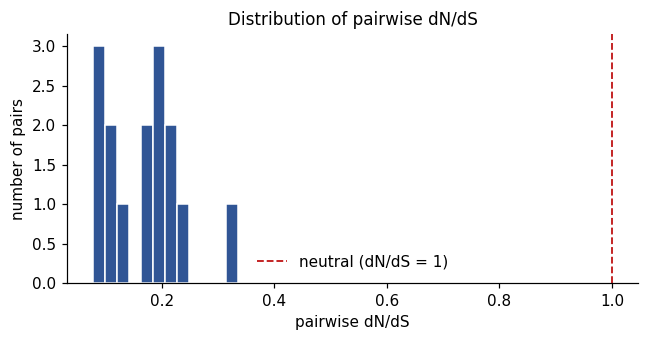

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(pairs["dN/dS"], bins=12, color=ACCENT, edgecolor="white")
ax.axvline(1.0, color=POS, ls="--", lw=1.2, label="neutral (dN/dS = 1)")
ax.set(xlabel="pairwise dN/dS", ylabel="number of pairs",
       title="Distribution of pairwise dN/dS")
ax.legend(frameon=False)
fig.tight_layout()

*Figure 1. Histogram of pairwise dN/dS across all strain pairs. Every pair falls well below the dashed neutral line at dN/dS = 1 — the signature of a gene set under purifying selection.*

## 2 · Per-gene pN/pS from a VCF

`eskaks vcf` measures selection *within* a species from a VCF, a reference and a
GFF3. Here we run the toy *M. tuberculosis*-style genome with genetic code 11,
add the **per-variant table** (`--variants`), wire in a divergence file for the
polymorphism-vs-divergence panel, and write the interactive HTML report.

In [5]:
eskaks(
    "vcf",
    "--ref", "examples/toy_genome/reference.fasta",
    "--gff", "examples/toy_genome/genes.gff3",
    "--vcf", "examples/toy_genome/variants.vcf",
    "--divergence", "examples/toy_genome/divergence.tsv",
    "--genetic-code", "11", "--variants", "--report",
    "-o", OUT / "vcf",
);

── pN/pS Summary ──────────────────────────
  Genes analyzed:      12
  Genes with SNPs:     12
  SNPs used (in CDS):  264 of 264 parsed
  Total synonymous:    115.00
  Total nonsynonymous: 149.00
  ── Genome-wide (pooled) ──────────────────
  N / S sites:         3200.3 / 1101.7
  Overall pN / pS:     0.046558 / 0.104384
  Overall pN/pS:       0.446028
  Selection:           purifying selection (pN/pS < 1)
  ── Neutrality test (pN/pS = 1) ───────────
  Genes tested:        12
  Significant genes:   7  (BH-FDR < 0.05)
───────────────────────────────────────────
  Output:
    nb_out/vcf_pnps.tsv
    nb_out/vcf_variants.tsv
    nb_out/vcf_report.html
───────────────────────────────────────────


The per-gene table carries the ratio, its Wilson CI, SNP counts and the neutrality test. Top genes by significance:

In [6]:
pnps = pd.read_csv(OUT / "vcf_pnps.tsv", sep="\t")
pnps["P_value"] = pd.to_numeric(pnps["P_value"], errors="coerce")
cols = ["Gene", "pN/pS", "pN/pS_lo", "pN/pS_hi", "Nonsyn_SNPs", "Syn_SNPs", "P_value", "Q_value_BH"]
pnps.sort_values("P_value").head(8)[cols]

,Gene,pN/pS,pN/pS_lo,pN/pS_hi,Nonsyn_SNPs,Syn_SNPs,P_value,Q_value_BH
6,gene07,0.068336,0.016994,0.274798,2.0,11.0,0.000055,0.000665
2,gene03,0.123511,0.041541,0.367231,4.0,11.0,0.000265,0.001589
0,gene01,0.225889,0.103527,0.492876,10.0,15.0,0.000497,0.001987
1,gene02,0.268339,0.130208,0.553007,12.0,17.0,0.000868,0.002605
11,gene12,0.296531,0.133656,0.657887,11.0,12.0,0.007614,0.018273
5,gene06,0.347930,0.161780,0.748273,13.0,12.0,0.017016,0.034032
10,gene11,0.367799,0.171018,0.791004,13.0,12.0,0.024027,0.041190
3,PPE_toy1,1.617051,0.573616,4.558546,18.0,4.0,0.541471,0.794217


### The variants behind each gene (`--variants`)

A per-gene ratio is a summary; to act on a hit you need the actual mutations.
The `Change` column (`S315T`-style) is the key you join to a resistance
catalogue. Note that **nonsense** (stop-gain) changes are listed here even though
they are excluded from the pN/pS counts.

In [7]:
variants = pd.read_csv(OUT / "vcf_variants.tsv", sep="\t")
variants.head(10)

,Gene,Chrom,Pos,Strand,Ref,Alt,AA_Pos,Ref_AA,Alt_AA,Change,AF,Effect
0,gene01,chr1,6,+,C,G,2,A,A,A2A,0.130,synonymous
1,gene01,chr1,12,+,G,A,4,L,L,L4L,0.145,synonymous
2,gene01,chr1,14,+,C,T,5,S,L,S5L,0.995,missense
3,gene01,chr1,17,+,T,C,6,L,P,L6P,0.225,missense
4,gene01,chr1,27,+,G,C,9,M,I,M9I,0.538,missense
5,gene01,chr1,63,+,T,C,21,C,C,C21C,0.119,synonymous
6,gene01,chr1,67,+,G,C,23,V,L,V23L,0.556,missense
7,gene01,chr1,74,+,G,T,25,R,I,R25I,0.405,missense
8,gene01,chr1,86,+,T,C,29,L,P,L29P,0.281,missense
9,gene01,chr1,93,+,A,T,31,A,A,A31A,0.106,synonymous


### Volcano plot

Direction (log2 pN/pS) vs confidence (−log10 p). Points left of centre are under
purifying selection, right are diversifying; the dashed line is the significance
threshold.

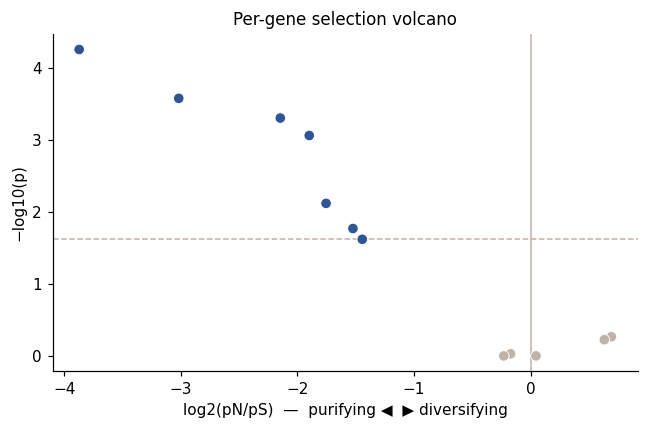

In [8]:
d = pnps.dropna(subset=["P_value"]).copy()
d = d[(d["pN/pS"] != "NaN") & (d["pN/pS"] != "inf")]
d["ratio"] = pd.to_numeric(d["pN/pS"], errors="coerce")
d = d[d["ratio"] > 0]
d["x"] = np.log2(d["ratio"])
d["y"] = -np.log10(d["P_value"].clip(lower=1e-300))
q = pd.to_numeric(pnps["Q_value_BH"], errors="coerce")
thr = d["y"][d.index.isin(q[q <= 0.05].index)].min() if (q <= 0.05).any() else np.inf

def colour(row):
    sig = row["y"] >= (thr if np.isfinite(thr) else np.inf)
    if not sig:
        return NS
    return POS if row["x"] > 0 else ACCENT

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(d["x"], d["y"], c=[colour(r) for _, r in d.iterrows()],
           s=48, edgecolor="white", linewidth=0.6, zorder=3)
ax.axvline(0, color=NS, lw=1)
if np.isfinite(thr):
    ax.axhline(thr, color=NS, ls="--", lw=1)
ax.set(xlabel="log2(pN/pS)  —  purifying ◀  ▶ diversifying",
       ylabel="−log10(p)", title="Per-gene selection volcano")
fig.tight_layout()

*Figure 2. Per-gene selection volcano: log2(pN/pS) on the x-axis (purifying selection at left, diversifying at right) against -log10(p-value) on the y-axis. Points above the dashed FDR significance line are the significant genes; colour marks direction.*

## 3 · Population diversity (`--diversity`)

pN/pS counts each SNP once. For within-species polymorphism you usually also want
**nucleotide diversity** (πN/πS) and an **SFS neutrality test** (Tajima's D).
These need the sample size, so `--diversity` requires a multi-sample VCF — here a
small 4-sample example.

In [9]:
eskaks(
    "vcf",
    "--ref", "tests/data/pnps_hand_ref.fasta",
    "--gff", "tests/data/pnps_hand.gff3",
    "--vcf", "tests/data/pnps_multisample.vcf",
    "--genetic-code", "11", "--diversity",
    "-o", OUT / "div",
);

── Genome-wide diversity (n=4) ───────────
  Segregating coding SNPs: 3
  piN / piS (per site):    1.304e-1 / 5.000e-1
  piN/piS:                 0.2609
  Watterson theta (site):  1.818e-1
  Tajima's D:              0.1677

── pN/pS Summary ──────────────────────────
  Genes analyzed:      1
  Genes with SNPs:     1
  SNPs used (in CDS):  3 of 3 parsed
  Total synonymous:    1.00
  Total nonsynonymous: 2.00
  ── Genome-wide (pooled) ──────────────────
  N / S sites:         7.7 / 1.3
  Overall pN / pS:     0.260870 / 0.750000
  Overall pN/pS:       0.347826
  Selection:           purifying selection (pN/pS < 1)
  ── Neutrality test (pN/pS = 1) ───────────
  Genes tested:        1
  Significant genes:   0  (BH-FDR < 0.05)
───────────────────────────────────────────
  Output:
    nb_out/div_pnps.tsv
    nb_out/div_diversity.tsv
───────────────────────────────────────────


In [10]:
pd.read_csv(OUT / "div_diversity.tsv", sep="\t")

,Gene,Chrom,N_samples,S_seg,piN,piS,piN/piS,Theta_W,Tajima_D
0,gval,val1,4,3,0.130435,0.5,0.26087,0.181818,0.167656


## Next steps

- Open **`nb_out/vcf_report.html`** in a browser — the full interactive dashboard
  (Manhattan, volcano, QQ, McDonald-Kreitman) with a colour-blind mode and
  CSV/JSON/Print export.
- No data yet? `eskaks --demo` runs a complete analysis on bundled data with no
  input files.
- Read the [interpreting-results](../interpreting-results/) guide, the
  [VCF analysis](../vcf-analysis/) reference, or the [glossary](../glossary/).

*Every number above was produced by the compiled `eskaks` binary when this
notebook was executed — the outputs are real, not illustrative.*